In [298]:
import os

In [299]:
# %%capture --no-stderr
# %pip install -U langgraph langchain_groq langgraph trustcall langchain_core langchain_community langchain-tavily langgraph-prebuilt

In [301]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [302]:
from pydantic import BaseModel, Field
from typing import Optional
import json

class ArchInputState(BaseModel):
    current_sequence: str = Field(..., description="Current architecture sequence")
    context: str = Field(default="", description="Additional context about the system being designed")

class ArchOutputState(BaseModel):
    explanation: str = Field(..., description="Why this component logically follows from the previous components")
    next: str = Field(..., description="Next component name or '__end__' to stop the sequence")
    current_sequence: str = Field(..., description="Updated full architecture sequence with the new component")
    reasoning: str = Field(..., description="Detailed architectural reasoning for this choice")

# Test the schemas
print("Schemas defined successfully!")
sample_input = ArchInputState(current_sequence="user req -> load balancer", context="distributed job scheduler")
sample_output = ArchOutputState(
    explanation="API gateway handles routing and authentication",
    next="api gateway", 
    current_sequence="user req -> load balancer -> api gateway",
    reasoning="In distributed systems, API gateways provide centralized request routing, authentication, and rate limiting"
)
print("Sample Input:", sample_input.model_dump())
print("Sample Output:", sample_output.model_dump())

Schemas defined successfully!
Sample Input: {'current_sequence': 'user req -> load balancer', 'context': 'distributed job scheduler'}
Sample Output: {'explanation': 'API gateway handles routing and authentication', 'next': 'api gateway', 'current_sequence': 'user req -> load balancer -> api gateway', 'reasoning': 'In distributed systems, API gateways provide centralized request routing, authentication, and rate limiting'}


In [303]:
class StructuredArchitectureState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    input_state: ArchInputState
    output_state: Optional[ArchOutputState]
    is_complete: bool
    iteration_count: int  # Track iterations for recursion limit

# Test the state
print("Structured state class defined successfully with iteration tracking!")
test_state = StructuredArchitectureState(
    messages=[],
    input_state=ArchInputState(current_sequence="user req -> load balancer", context="job scheduler"),
    output_state=None,
    is_complete=False,
    iteration_count=0
)
print("Test state created:", test_state["input_state"].current_sequence)

Structured state class defined successfully with iteration tracking!
Test state created: user req -> load balancer


In [304]:
# Test with different models to isolate the issue
from langchain_groq import ChatGroq

print("🔬 Testing different models:")

# Try Gemma (should work with PydanticOutputParser)
gemma_chat = ChatGroq(model="gemma2-9b-it", temperature=0)
deepseek_chat = ChatGroq(model="deepseek-r1-distill-llama-70b", temperature=0)

# Test which model works better
test_models = {
    "gemma": gemma_chat,
    "deepseek": deepseek_chat
}

print("Available models:", list(test_models.keys()))

chat_model = gemma_chat

🔬 Testing different models:
Available models: ['gemma', 'deepseek']


In [305]:
from langchain.prompts import PromptTemplate

system_prompt = PromptTemplate(
    template="""
You are an expert in software architecture and high-level design (HLD). Your task is to help build system architecture flows by predicting logical next components.

When a user provides an initial architecture sequence, you should:
1. Use the next_node_predictor tool to get the next logical component
2. Explain why this component makes sense in the architecture 
3. Show the updated sequence: "current_sequence -> predicted_component"
4. Ask if they want to continue building the architecture or if they're satisfied

Guidelines:
- Always use the tool for predictions, don't guess
- Be conversational and explain your architectural reasoning
- Build the sequence progressively: user req -> load balancer -> api gateway -> etc.
- Stop after 3-4 predictions unless user explicitly asks to continue
- Focus on high-level components, not implementation details

Example interaction:
User: "user req -> load balancer"
Assistant: *calls tool* → predicts "api gateway"
Assistant: "Great! After the load balancer, an API gateway makes sense to handle routing and authentication. 
Current architecture: user req -> load balancer -> api gateway
Would you like me to continue building this architecture?"
"""
)

In [306]:
from langchain_core.output_parsers import PydanticOutputParser

# Force PydanticOutputParser approach (Groq models don't properly support with_structured_output)
print("📦 Using PydanticOutputParser for Groq model")
parser = PydanticOutputParser(pydantic_object=ArchOutputState)
format_instructions = parser.get_format_instructions()
llm_structured = chat_model | parser

# Improved structured prompt with better guidance
from langchain_core.prompts import ChatPromptTemplate

structured_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert system architect predicting the next logical component in a system flow.

{format_instructions}

IMPORTANT GUIDELINES:
1. **Next Component Logic**: Predict the very next component that should logically follow in the architecture flow
2. **Component Examples**: api-gateway, service-mesh, cache (redis), database (postgres), message-queue, worker-pool, job-scheduler, storage, monitoring, auth-service
3. **Sequence Building**: Always append the new component to current_sequence with " -> new_component"
4. **Completion Rules**: 
   - Use "next": "__end__" ONLY when the system is architecturally complete (typically 4-6 components)
   - Continue building if the flow needs more components
   - Context: {context}

EXAMPLE FLOWS:
- Job Scheduler: user req -> load balancer -> api gateway -> job scheduler -> message queue -> worker nodes -> database
- Web App: user req -> load balancer -> api gateway -> cache -> microservices -> database

Think step by step:
1. What is the current sequence missing?
2. What would be the very next logical component?
3. Is the system complete or needs more components?"""),
    ("human", "Current sequence: {current_sequence}\n\nWhat should be the NEXT component in this architecture?")
])

structured_prompt = structured_prompt.partial(format_instructions=format_instructions)

print("🎯 Improved structured prompt with better next component guidance!")

📦 Using PydanticOutputParser for Groq model
🎯 Improved structured prompt with better next component guidance!


In [307]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

def pure_structured_assistant(state: StructuredArchitectureState):
    """Pure structured output assistant with recursion limit handling"""
    try:
        # Check if we've hit reasonable iteration limits (before running out of recursion limit)
        max_iterations = 6  # Reasonable limit for architecture components
        current_iteration = state.get("iteration_count", 0) + 1
        
        if current_iteration >= max_iterations:
            # Force completion when approaching limit
            completion_output = ArchOutputState(
                explanation=f"Architecture complete after {current_iteration} components",
                next="__end__",
                current_sequence=state["input_state"].current_sequence,
                reasoning=f"Reached maximum iteration limit ({max_iterations}), system architecture is sufficiently complete"
            )
            
            return {
                "messages": [AIMessage(content=f"🏁 Architecture complete after {current_iteration} iterations")],
                "output_state": completion_output,
                "is_complete": True,
                "iteration_count": current_iteration
            }
        
        # Build input for structured chain
        chain_input = {
            "current_sequence": state["input_state"].current_sequence,
            "context": state["input_state"].context
        }
        
        # Direct structured output call
        chain = structured_prompt | llm_structured
        output: ArchOutputState = chain.invoke(chain_input)
        
        # Create AI message
        ai_message = AIMessage(
            content=f"Added: {output.next} | Sequence: {output.current_sequence} | Iteration: {current_iteration}"
        )
        
        # Determine completion
        is_complete = output.next == "__end__"
        
        return {
            "messages": [ai_message],
            "output_state": output,
            "is_complete": is_complete,
            "iteration_count": current_iteration
        }
        
    except Exception as e:
        # Error handling with fallback
        error_output = ArchOutputState(
            explanation=f"Error: {str(e)}",
            next="__end__",
            current_sequence=state["input_state"].current_sequence,
            reasoning="Stopping due to error"
        )
        
        return {
            "messages": [AIMessage(content=f"❌ Error: {str(e)}")],
            "output_state": error_output,
            "is_complete": True,
            "iteration_count": state.get("iteration_count", 0) + 1
        }

print("🔧 Assistant updated with recursion limit handling!")

🔧 Assistant updated with recursion limit handling!


In [308]:
def update_state_node(state: StructuredArchitectureState):
    """Update state node - preserves iteration count and handles completion properly"""
    
    if not state["output_state"] or state["is_complete"]:
        return {"is_complete": True}
    
    output_state = state["output_state"]
    current_iteration = state.get("iteration_count", 0)
    
    # Continue if we haven't reached the end
    if output_state.next != "__end__" and not state["is_complete"]:
        # Create new input state for next iteration
        new_input = ArchInputState(
            current_sequence=output_state.current_sequence,
            context=state["input_state"].context
        )
        
        return {
            "input_state": new_input,
            "is_complete": False,
            "iteration_count": current_iteration  # Preserve count
        }
    
    # Mark complete
    return {"is_complete": True}

print("🔄 State management updated with iteration count preservation!")

🔄 State management updated with iteration count preservation!


🎯 Clean graph created - NO tools, NO complexity!


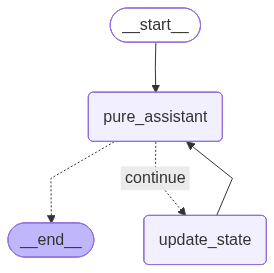

In [309]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

# Simplified graph - NO tools, NO tool conditions, NO tool nodes
builder = StateGraph(StructuredArchitectureState)

# Define nodes (clean and simple)
builder.add_node("pure_assistant", pure_structured_assistant)
builder.add_node("update_state", update_state_node)

# Simple conditional function (no tools_condition)
def should_continue_simple(state: StructuredArchitectureState) -> str:
    """Simple conditional - just check completion"""
    if state["is_complete"]:
        return "__end__"
    if state["output_state"] and state["output_state"].next == "__end__":
        return "__end__"
    return "continue"

# Define edges (clean flow)
builder.add_edge(START, "pure_assistant")
builder.add_conditional_edges(
    "pure_assistant",
    should_continue_simple,
    {"continue": "update_state", "__end__": END}
)
builder.add_edge("update_state", "pure_assistant")

# Compile the clean graph
clean_graph = builder.compile()

# Display
print("🎯 Clean graph created - NO tools, NO complexity!")
display(Image(clean_graph.get_graph(xray=True).draw_mermaid_png()))

In [310]:
from langgraph.checkpoint.memory import MemorySaver

# Create memory and compile clean graph
memory = MemorySaver()
clean_graph_memory = builder.compile(checkpointer=memory)

print("✅ Clean structured graph with memory compiled!")

✅ Clean structured graph with memory compiled!


In [311]:
# Test the IMPROVED structured architecture flow with recursion handling
config = {
    "configurable": {"thread_id": "improved_test_1"},
    "recursion_limit": 15
}

# Create initial state with iteration tracking
initial_state = StructuredArchitectureState(
    messages=[HumanMessage(content="Building distributed job scheduler architecture")],
    input_state=ArchInputState(
        current_sequence="user req -> load balancer",
        context="distributed job scheduler for batch processing tasks"
    ),
    output_state=None,
    is_complete=False,
    iteration_count=0  # Start iteration counting
)

print("🚀 Testing IMPROVED structured flow with recursion handling...")
print(f"📋 Initial: {initial_state['input_state'].current_sequence}")
print(f"🎯 Context: {initial_state['input_state'].context}")
print(f"🔢 Starting iteration: {initial_state['iteration_count']}")
print("-" * 70)

try:
    # Run the improved graph
    result = clean_graph_memory.invoke(initial_state, config)
    
    print("✅ Architecture generation SUCCESSFUL!")
    final_sequence = result['output_state'].current_sequence if result['output_state'] else 'No output'
    final_iterations = result.get('iteration_count', 0)
    print(f"🏁 Final sequence: {final_sequence}")
    print(f"🔢 Total iterations: {final_iterations}")
    print("-" * 70)
    
    # Display structured predictions with iteration info
    prediction_count = 0
    for i, message in enumerate(result["messages"]):
        if message.type == "ai" and not message.content.startswith("❌"):
            prediction_count += 1
            print(f"🤖 {message.content}")
    
    # Show final structured output details
    if result["output_state"]:
        output = result["output_state"]
        print(f"\n📊 Final Architecture Details:")
        print(f"  🎯 Next Component: {output.next}")
        print(f"  💭 Explanation: {output.explanation}")
        print(f"  🔄 Complete Sequence: {output.current_sequence}")
        print(f"  🧠 Reasoning: {output.reasoning}")
        print(f"  🔁 Final Iteration Count: {final_iterations}")
    
    print(f"\n🏆 SUCCESS: Proper recursion handling implemented!")
    
except Exception as e:
    print(f"❌ Error: {str(e)}")
    import traceback
    traceback.print_exc()

🚀 Testing IMPROVED structured flow with recursion handling...
📋 Initial: user req -> load balancer
🎯 Context: distributed job scheduler for batch processing tasks
🔢 Starting iteration: 0
----------------------------------------------------------------------
✅ Architecture generation SUCCESSFUL!
🏁 Final sequence: user req -> load balancer -> api-gateway -> job-scheduler -> message-queue -> worker-pool -> database
🔢 Total iterations: 6
----------------------------------------------------------------------
🤖 Added: api-gateway | Sequence: user req -> load balancer -> api-gateway | Iteration: 1
🤖 Added: job-scheduler | Sequence: user req -> load balancer -> api-gateway -> job-scheduler | Iteration: 2
🤖 Added: message-queue | Sequence: user req -> load balancer -> api-gateway -> job-scheduler -> message-queue | Iteration: 3
🤖 Added: worker-pool | Sequence: user req -> load balancer -> api-gateway -> job-scheduler -> message-queue -> worker-pool | Iteration: 4
🤖 Added: database | Sequence: u

In [312]:
last = result["messages"][-1]
if getattr(last, "type", None) == "ai":
    print("\nAssistant:", last.content)
else:
    last_ai = next((m for m in reversed(result["messages"]) if isinstance(m, AIMessage) or getattr(m, "type", "") == "ai"), None)
    if last_ai:
        print("\nAssistants:", last_ai.content)


Assistant: 🏁 Architecture complete after 6 iterations
